In [179]:
import pandas as pd

In [180]:
data = pd.read_csv('/content/golf_df.csv')

In [181]:
data

,Outlook,Temperature,Humidity,Windy,Play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [183]:
data['Outlook'].unique()

array(['sunny', 'overcast', 'rainy'], dtype=object)

In [184]:
data['Humidity'].unique()

array(['high', 'normal'], dtype=object)

In [185]:
data['Temperature'].unique()

array(['hot', 'mild', 'cool'], dtype=object)

In [186]:
from sklearn.preprocessing import LabelEncoder

In [187]:
le = LabelEncoder()

In [189]:
data.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play'], dtype='object')

In [191]:
for cols in data.columns:
  data[cols] = le.fit_transform(data[cols])

In [192]:
data

,Outlook,Temperature,Humidity,Windy,Play
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1
5,1,0,1,1,0
6,0,0,1,1,1
7,2,2,0,0,0
8,2,0,1,0,1
9,1,2,1,0,1


In [193]:
from sklearn.tree import DecisionTreeClassifier

In [194]:
dstr = DecisionTreeClassifier()

In [199]:
X = data.iloc[:,:-1].values

In [200]:
y = data.iloc[:,-1].values

In [202]:
from sklearn.model_selection import train_test_split as tts

In [203]:
X_train, X_test, y_train, y_test = tts(X,y, random_state=44, train_size= 0.7)

In [204]:
dstr.fit(X_train, y_train)

DecisionTreeClassifier()

In [205]:
from sklearn import tree

In [206]:
from matplotlib import pyplot as plt

[Text(0.6666666666666666, 0.875, 'x[2] <= 0.5\ngini = 0.444\nsamples = 9\nvalue = [3, 6]'), Text(0.5, 0.625, 'x[3] <= 0.5\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'), Text(0.5833333333333333, 0.75, 'True  '), Text(0.3333333333333333, 0.375, 'x[0] <= 1.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'), Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'), Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'), Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'), Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'), Text(0.75, 0.75, '  False')]


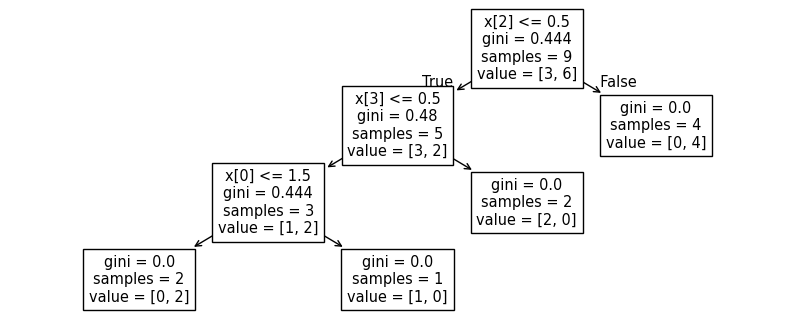

In [211]:
plt.figure(figsize=(10,4))
print(tree.plot_tree(dstr))

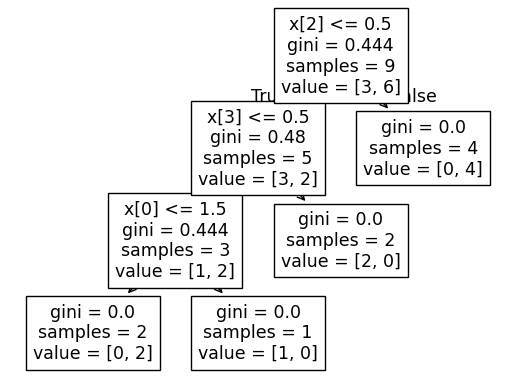

In [212]:
plt.show(tree.plot_tree(dstr))

In [213]:
from sklearn.tree import export_graphviz

In [214]:
feature_names = ['Outlook','Temperature','Humidity','Wind']
output = ['yes','no']
dot = export_graphviz(decision_tree=dstr, out_file='golf.dot', feature_names=feature_names, class_names=output)

In [215]:
! dot -T png golf.dot -o tree.png